In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util

DPI = 300
CMAP = "RdPu"

FOLDER = "/Users/brendan/Projects/trails/data/"


datafiles = [
    "example-fig|2025-12-12/data.json",
]

smallexample = "example-small|2026-01-23/data.json"

In [4]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

ratios: [100.0]
patch recovery: [0.001]
max costs: [2.0]
boundary conditions: ['SOLID']
num locations: [16]
random walker seeds: 1
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
steps: 40000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy', 'ratio'],
      dtype='object')


In [8]:
df_small = util.load_data(FOLDER + smallexample)
util.describe(df_small)

ratios: [100.0]
patch recovery: [0.001]
max costs: [2.0]
boundary conditions: ['SOLID']
num locations: [16]
random walker seeds: 1
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
steps: 20000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches', 'locations', 'walkers',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy', 'ratio'],
      dtype='object')


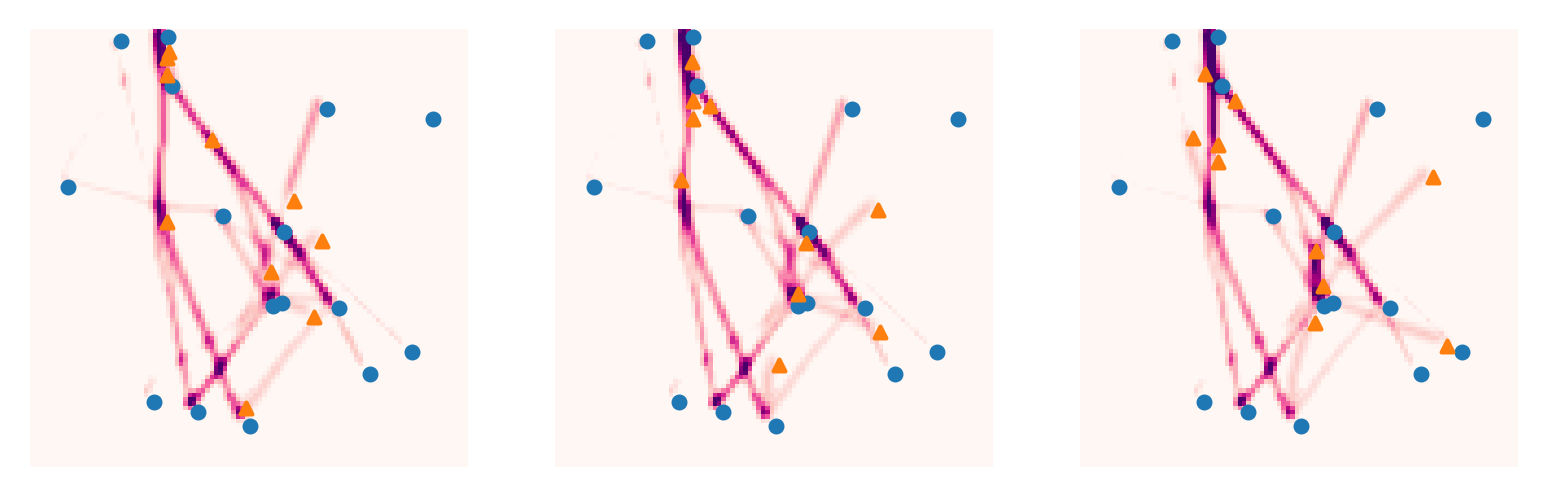

In [37]:
START = 180
END = 200

_df = df_small

MARKER_SIZE = 8 

ly = [p[1] for p in df_small["locations"][0]]
lx = [p[0] for p in df_small["locations"][0]]

STEPS = np.linspace(START, END, num=3)
fig, axs = plt.subplots(1, 3, dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(STEPS):
    row = _df[(_df["steps"] == steps)].iloc[0]
    
    
    axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=.4)
    axs[i].axis('off')
    # axs[i].set_title(steps)
    axs[i].scatter(lx, ly, s=MARKER_SIZE)
    
    wy = [p[1] for p in row["walkers"]]
    wx = [p[0] for p in row["walkers"]]
    axs[i].scatter(wx, wy, marker="^", s=MARKER_SIZE)


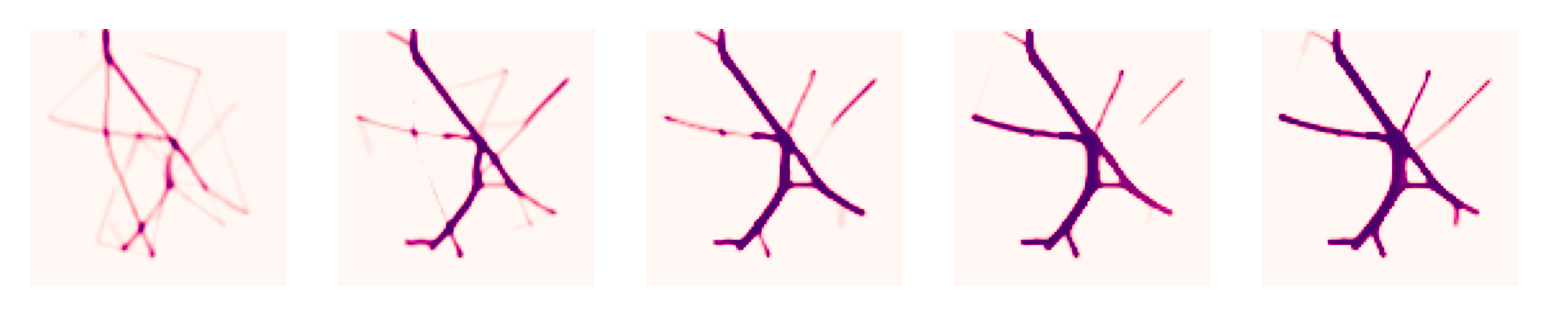

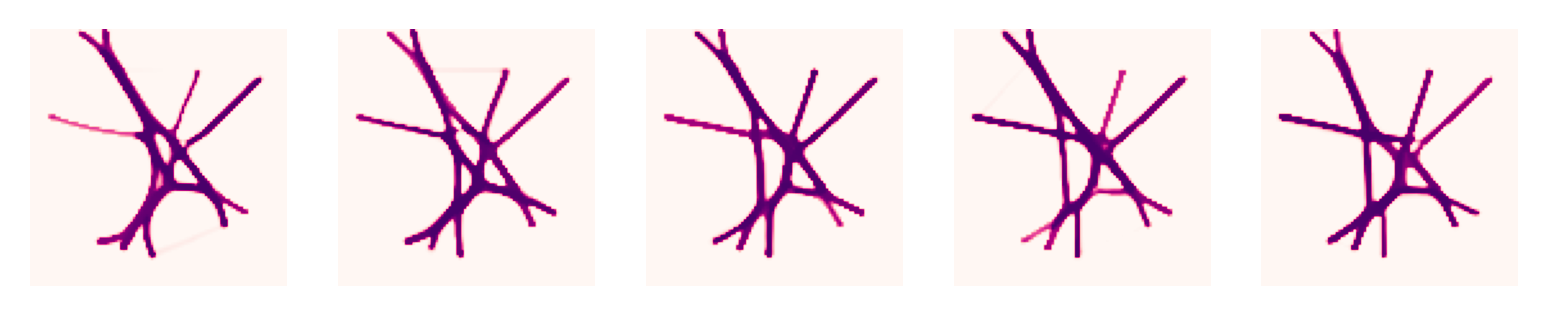

In [86]:
MID = 2000
END = 20000

STEPS = np.linspace(0, MID, num=6)
fig, axs = plt.subplots(1, 5, dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(STEPS[1:]):
    row = df[(df["steps"] == steps)].iloc[0]
    axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
    axs[i].axis('off')

STEPS = np.linspace(MID, END, num=6)
fig, axs = plt.subplots(1, 5, dpi=DPI)
# plt.subplots_adjust(wspace=0.5, hspace=0.2)
for i, steps in enumerate(STEPS[1:]):
    row = df[(df["steps"] == steps)].iloc[0]
    axs[i].imshow(np.reshape(row["patches"], (100, 100)), cmap=CMAP, vmin=0, vmax=1)
    axs[i].axis('off')